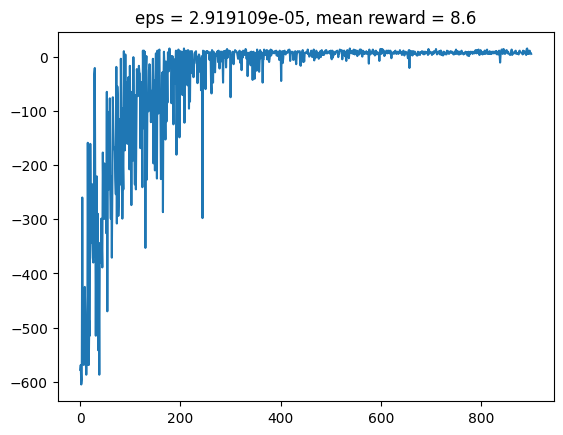

first state: [-0.00199647 -0.00293519  0.03797426  0.04989532]


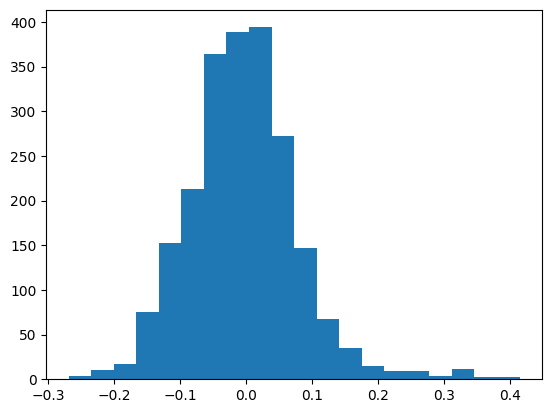

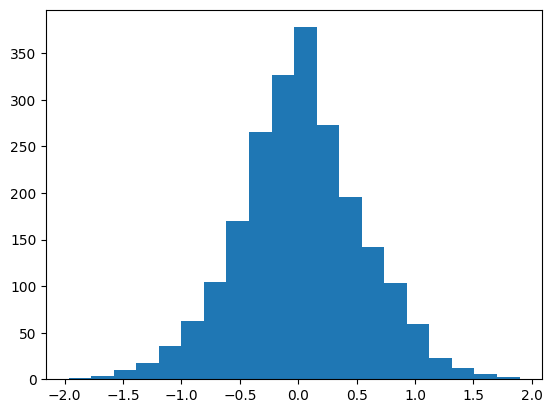

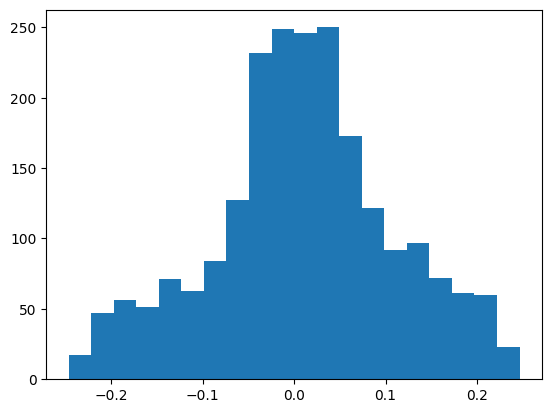

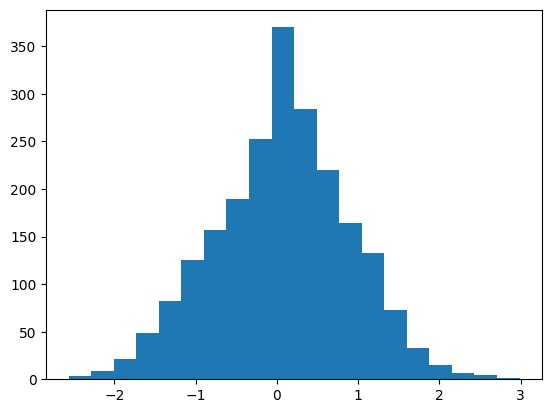

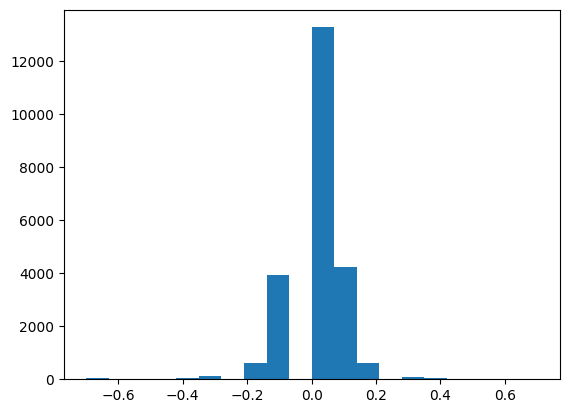

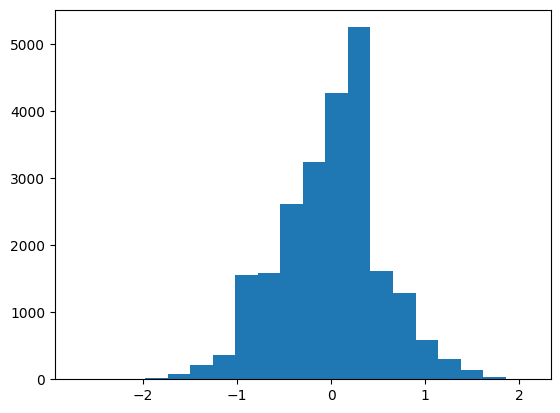

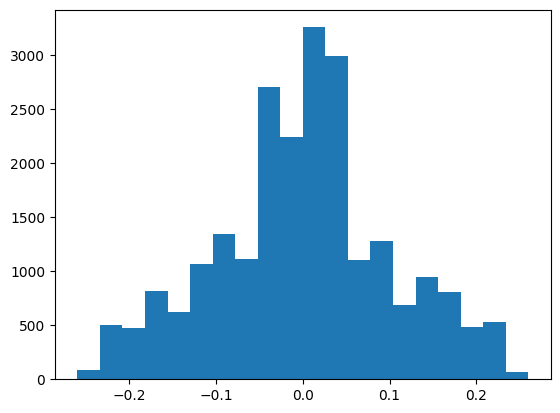

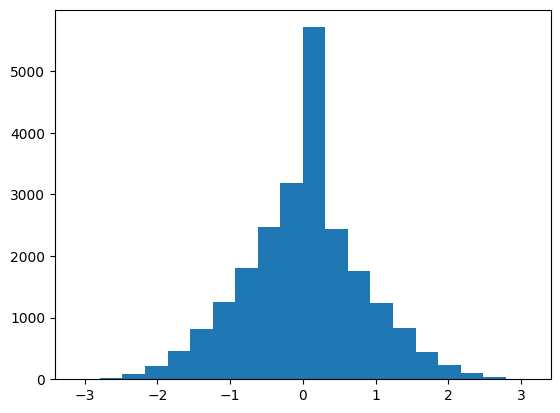

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math
import gymnasium as gym
from IPython.display import clear_output
from gymnasium import ObservationWrapper
import warnings

warnings.filterwarnings("ignore")

# 1. Класс QLearningAgent


class QLearningAgent:

    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """Конструктор агента"""
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0.0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """Возвращает Q(state, action)"""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Устанавливает Qvalue для [state, action]  в определенное значение"""
        self._qvalues[state][action] = value

    def get_value(self, state):
        """
        Вычисляет оценку агента V(s) по текущим q-значениям.
        V(s) = max_over_action Q(state, action) по возможным действиям.
        """
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0

        q_values = [self.get_qvalue(state, a) for a in possible_actions]
        value = max(q_values)
        return value

    def update(self, state, action, reward, next_state):
        """
        Обновляет Q-значение по правилу Q-обучения:
        Q(s, a) := (1 - alpha) * Q(s, a) + alpha * (r + gamma * V(s'))
        """
        gamma = self.discount
        learning_rate = self.alpha

        target_value = reward + gamma * self.get_value(next_state)
        current_q = self.get_qvalue(state, action)
        new_q_value = (1 - learning_rate) * current_q + learning_rate * target_value
        self.set_qvalue(state, action, new_q_value)

    def get_best_action(self, state):
        """
        Возвращает лучшее действие для состояния.
        """
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None

        best_action = max(possible_actions, key=lambda a: self.get_qvalue(state, a))
        return best_action

    def get_action(self, state):
        """
        Возвращает действие, которое нужно предпринять в текущем состоянии.
        """
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None

        epsilon = self.epsilon

        if random.random() < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        return chosen_action


# 2. Обучение в Taxi-v3

env = gym.make("Taxi-v3")
n_actions = env.action_space.n

agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions)
)


def play_and_train(env, agent, t_max=10**4):
    """
    Эта функция должна
     - запустить полную игру, действия заданы политикой e-greeding агента
     - обучать агента, используя agent.update(...) всякий раз, когда это возможно
     - вернуть общую награду
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        a = agent.get_action(s)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward


rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title(
            "eps = {:e}, mean reward = {:.1f}".format(
                agent.epsilon, np.mean(rewards[-10:])
            )
        )
        plt.plot(rewards)
        plt.show()

# 3. Бинаризованные пространства состояний


def make_env():
    return gym.make("CartPole-v1")


env = make_env()
n_actions_cp = env.action_space.n
s, _ = env.reset()
print(f"first state: {s}")

seen_observations = []
for _ in range(100):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, terminated, truncated, _ = env.step(env.action_space.sample())
        done = terminated or truncated
        seen_observations.append(s)

seen_observations = np.array(seen_observations)

for obs_i in range(env.observation_space.shape[0]):
    plt.hist(seen_observations[:, obs_i], bins=20)
    plt.show()

# 4. Бинаризованная среда


class Binarizer(ObservationWrapper):
    """
    Обертка для среды, которая округляет (бинаризует) непрерывное состояние.
    """

    def observation(self, state):
        state = np.array(
            [
                round(state[0], 1),
                round(state[1], 1),
                round(state[2], 2),
                round(state[3], 1),
            ]
        )
        return tuple(state)


env2 = Binarizer(gym.make("CartPole-v1"))

seen_observations = []
for _ in range(1000):
    s, _ = env2.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, terminated, truncated, _ = env2.step(env2.action_space.sample())
        done = terminated or truncated
        seen_observations.append(s)
        if done:
            break

seen_observations = np.array(seen_observations)

for obs_i in range(env2.observation_space.shape[0]):
    plt.hist(seen_observations[:, obs_i], bins=20)
    plt.show()
